# Limpieza de los datos
En este notebook se realizara la limpieza siguiendo el análisis obtenido en el archivo eda_data.ipynb. Durante el análisis se ideintificaron las siguiente anomalías:
- Registros duplicados
- Transacciones sin identificación
- Cantidades y precios unitarios negativos
- Outliers en cantidades y precios unitarios

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# [DOC] Primero cargamos el dataset original y guardamos el conteo inicial para la auditoría final

df_raw = pd.read_csv('../../../data/raw/data.csv', encoding='ISO-8859-1')
df_working = df_raw.copy()
stats_cleaning = {"Registros Iniciales": len(df_raw)}

In [22]:
# [DOC] Una vez obtenido los datos, eliminamos los datos duplicados
initial_rows = df_working.shape[0]
df_working.drop_duplicates(inplace=True)
final_rows = df_working.shape[0]
stats_cleaning["Duplicados Eliminados"] = stats_cleaning["Registros Iniciales"] - len(df_working)
print(f"[INFO] Registros duplicados eliminados: {initial_rows - final_rows}")

[INFO] Registros duplicados eliminados: 5268


In [23]:
# [DOC] Ahora, eliminamos registros donde CustomerID es nulo

df_working = df_working.dropna(subset=['CustomerID'])
stats_cleaning["Nulos en ID Eliminados"] = (stats_cleaning["Registros Iniciales"] - stats_cleaning["Duplicados Eliminados"]) - len(df_working)
print(f"[INFO] Registros tras eliminar nulos en CustomerID: {df_working.shape[0]}")

[INFO] Registros tras eliminar nulos en CustomerID: 401604


In [24]:
# [DOC] Habiendo eliminado los duplicados y nulos, filtramos los datos para mantener solo cantidades y precios mayores a cero
df_working = df_working[(df_working['Quantity'] > 0) & (df_working['UnitPrice'] > 0)]
print(f"[INFO] Registros tras eliminar transacciones no comerciales: {df_working.shape[0]}")

[INFO] Registros tras eliminar transacciones no comerciales: 392692


In [25]:
# [DOC] Realicamos el cálculo de límites basados en el percentil 99 y aplicamos el filtro de outliers

q_limit = df_working['Quantity'].quantile(0.99)
p_limit = df_working['UnitPrice'].quantile(0.99)
df_working = df_working[(df_working['Quantity'] <= q_limit) & (df_working['UnitPrice'] <= p_limit)]

stats_cleaning["Registros Finales"] = len(df_working)

print(f"[INFO] Límite de Quantity aplicado: {q_limit}")
print(f"[INFO] Límite de UnitPrice aplicado: {p_limit}")
print(f"[INFO] Registros tras limpieza de outliers: {df_working.shape[0]}")

[INFO] Límite de Quantity aplicado: 120.0
[INFO] Límite de UnitPrice aplicado: 14.95
[INFO] Registros tras limpieza de outliers: 385081


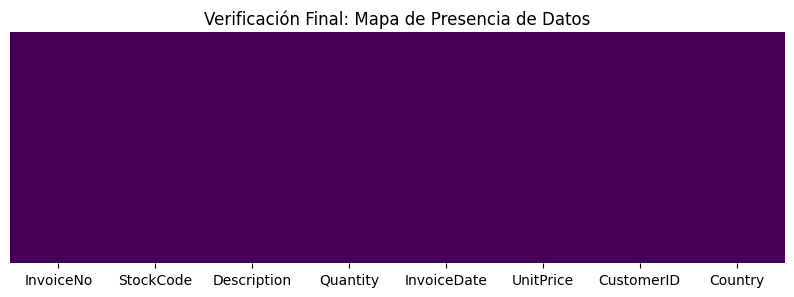

In [26]:
# [DOC] Comenzamos a verificar la integridad de los datos una vez realizada la limpieza, primero generamos un heatmap

plt.figure(figsize=(10, 3))
sns.heatmap(df_working.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Verificación Final: Mapa de Presencia de Datos')
plt.show()

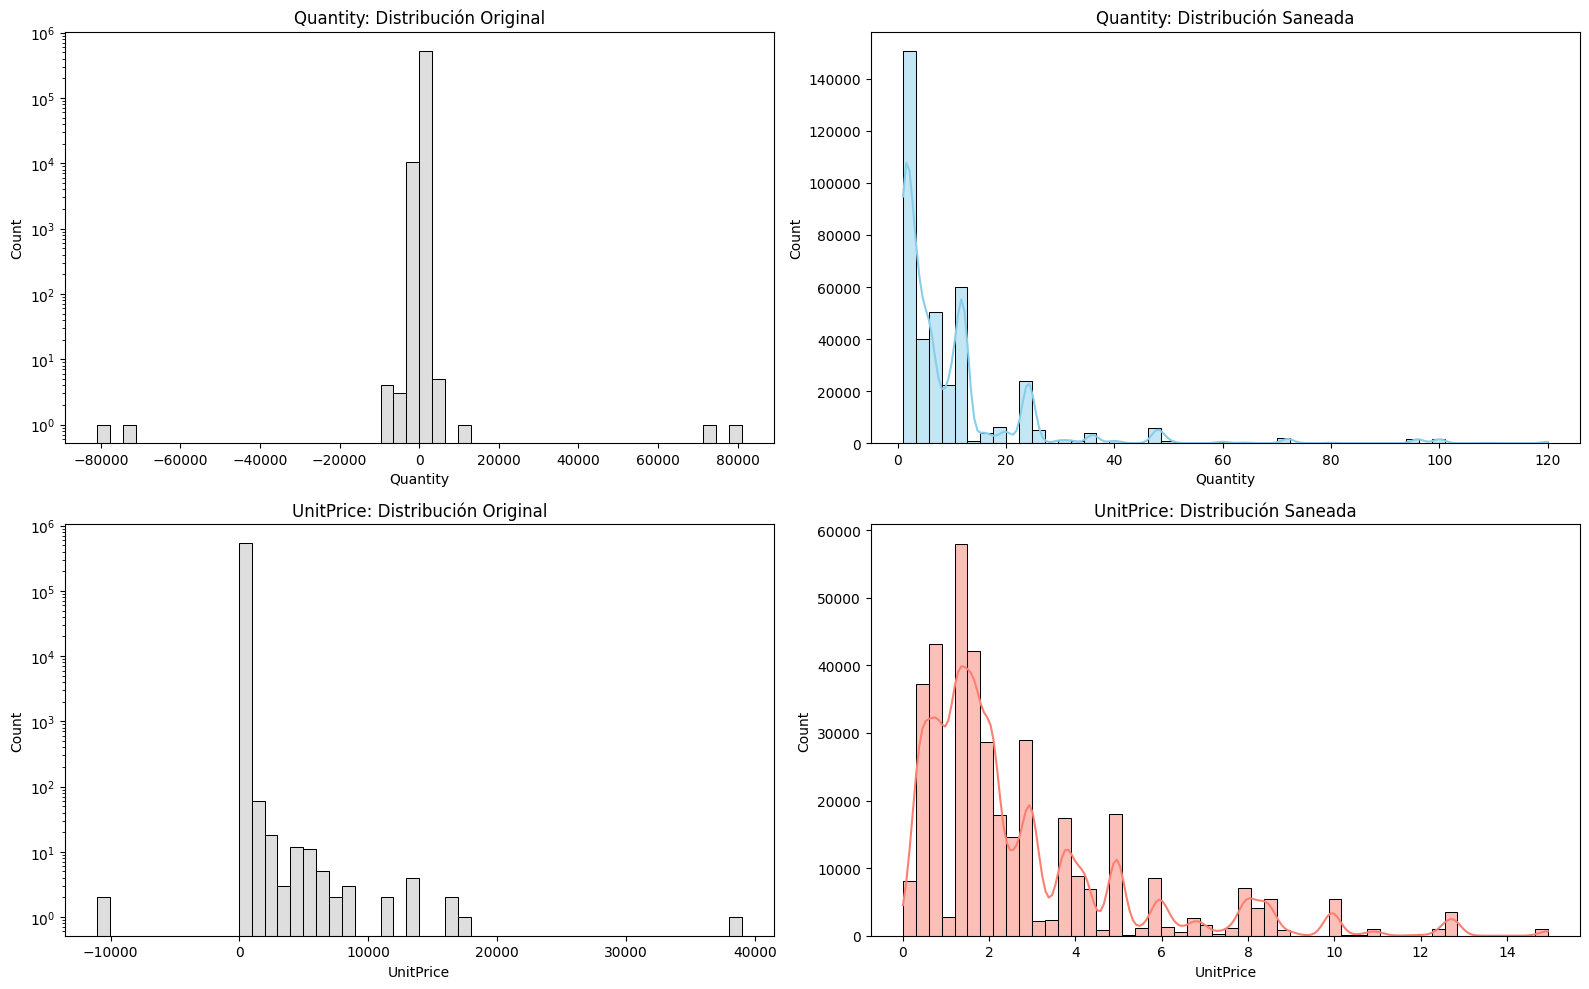

In [27]:
# [DOC] Ahora generamos comparativas entre los datos brutos y los datos limpios de los campos de cantidad y precio unitario

fig, ax = plt.subplots(2, 2, figsize=(16, 10))

# [DOC] Histograma para Quantity
sns.histplot(df_raw['Quantity'], bins=50, ax=ax[0,0], color='lightgrey', kde=False)
ax[0,0].set_title('Quantity: Distribución Original')
ax[0,0].set_yscale('log')

sns.histplot(df_working['Quantity'], bins=50, ax=ax[0,1], color='skyblue', kde=True)
ax[0,1].set_title('Quantity: Distribución Saneada')

# [DOC] Histograma para UnitPrice
sns.histplot(df_raw['UnitPrice'], bins=50, ax=ax[1,0], color='lightgrey', kde=False)
ax[1,0].set_title('UnitPrice: Distribución Original')
ax[1,0].set_yscale('log')

sns.histplot(df_working['UnitPrice'], bins=50, ax=ax[1,1], color='salmon', kde=True)
ax[1,1].set_title('UnitPrice: Distribución Saneada')

plt.tight_layout()
plt.show()

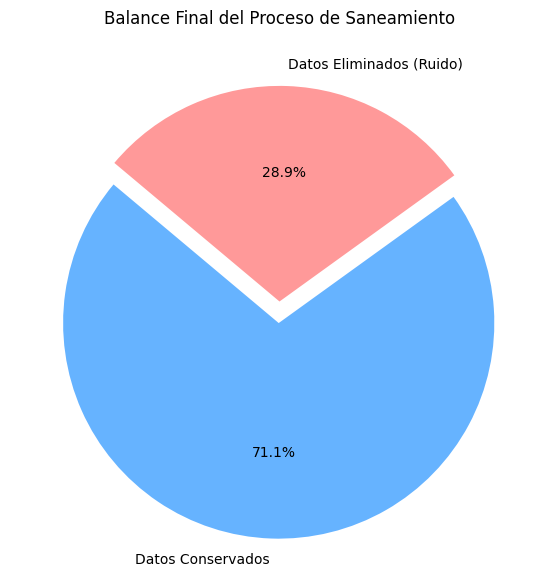

In [28]:
# [DOC] Esta última visualización es un balance de datos entre el dataset original y el dataset saneado

labels = ['Datos Conservados', 'Datos Eliminados (Ruido)']
sizes = [len(df_working), len(df_raw) - len(df_working)]

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'], explode=(0.1, 0))
plt.title('Balance Final del Proceso de Saneamiento')
plt.show()

In [29]:
# [DOC] Por último, exportamos los datos saneados y limpios

output_dir = '../../data/interim'
output_path = os.path.join(output_dir, 'data_sanitized.csv')

if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"[INFO] Carpeta creada: {output_dir}")

df_working.to_csv(output_path, index=False)

print(f"[SUCCESS] Proceso finalizado. Dataset guardado en: {output_path}")
print(f"[INFO] Resumen técnico: {stats_cleaning}")

[INFO] Carpeta creada: ../../data/interim
[SUCCESS] Proceso finalizado. Dataset guardado en: ../../data/interim\data_sanitized.csv
[INFO] Resumen técnico: {'Registros Iniciales': 541909, 'Duplicados Eliminados': 5268, 'Nulos en ID Eliminados': 135037, 'Registros Finales': 385081}
